# 02 — Latency budget (RQ2 / NFR2)

The participant- and researcher-client round-trip times are reported against the 100 ms budget. The decision-pipeline latency (`pipeline-decision`) and out-of-process decision round-trip (`decision-provider-rtt`) are recorded by the platform when an automated decision strategy runs; this dataset was operated in **manual** mode, so those roles are absent here (the instrumentation is available but unexercised).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import _lib
_lib.apply_style()
try:
    data = _lib.read_cache()
except FileNotFoundError:
    data = _lib.load_all(); _lib.write_cache(data)


In [2]:
tel = data.telemetry.copy()
print('roles present:', sorted(tel['role'].dropna().unique()))
rtt = tel[tel['role'].isin(['participant','researcher'])].dropna(subset=['rttMs'])
def stats(s):
    s = s.sort_values()
    return pd.Series({'n': len(s), 'p50': s.quantile(.5), 'p95': s.quantile(.95),
        'p99': s.quantile(.99), 'max': s.max(),
        'over_100ms_pct': 100*(s > _lib.LATENCY_BUDGET_MS).mean()})
by_role = rtt.groupby('role')['rttMs'].apply(stats).unstack().round(2)
_lib.save_table(by_role.reset_index(), 'client_rtt_by_role')
by_role

roles present: ['participant', 'researcher']


,n,p50,p95,p99,max,over_100ms_pct
role,,,,,,
participant,203.0,1.0,3.0,10.98,41.0,0.0
researcher,207.0,2.0,9.0,10.94,28.0,0.0


### Client RTT distribution vs the 100 ms budget

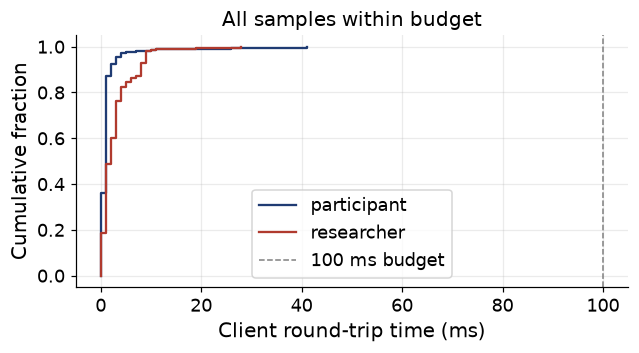

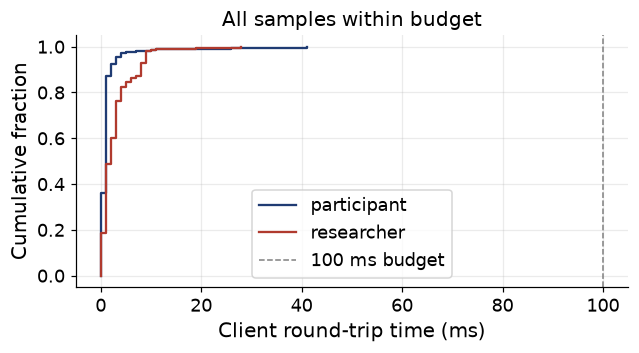

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.4))
for role, c in [('participant', _lib.CONDITION_COLORS['with']), ('researcher', _lib.CONDITION_COLORS['without'])]:
    s = np.sort(rtt.loc[rtt['role'] == role, 'rttMs'].values)
    if len(s):
        ax.step(s, np.linspace(0, 1, len(s)), where='post', label=role, color=c)
ax.axvline(_lib.LATENCY_BUDGET_MS, ls='--', c='gray', lw=1, label='100 ms budget')
ax.set_xlabel('Client round-trip time (ms)'); ax.set_ylabel('Cumulative fraction')
ax.set_title('All samples within budget'); ax.legend()
fig.tight_layout(); _lib.save_fig(fig, '02_client_rtt_ecdf'); fig

Sample rate and validity are also reported through the same telemetry channel (see notebook 01 for the sensing view).